# GLM Tuning-Variable Analysis (PFC, mFC dataset)

Port of the LEC GLM analysis pipeline (`code/LEC_glm_tuning_variables.ipynb`) to
the mPFC dataset under `mFC_data/data/`. Same model, same plots, same variants
— with two differences:

1. **No head direction.** The mFC dataset has no `HD_raw` recording, so HD is
   dropped from every fit via `regressors_to_include`. 8 regressors instead of
   9; default-bin design matrix is 91 cols (127 − 36 HD).
2. **Disk-loaded data.** The mFC dataset is a directory of `.npy` files rather
   than a pickle. `build_data_dic_from_pfc(data_folder, recdays)` (defined in
   the PFC sibling module) constructs the same nested-dict shape that
   `run_glm_analysis` consumes.

The substantive analyses (F-test significance, CPD / R² / ΔR², joint time-any
and distance-any groups, raised-cosine variant, 20-bin GP column-matched
variant, reference-coded sanity check) are unchanged from the LEC notebook.

## Method: per-regressor significance via permutation F-test

For each neuron, we fit a per-neuron OLS GLM:

    y_t = X_t β + ε_t

`X` is the design matrix of one-hot encoded task variables. PFC variables:
place (21 bins), goal progress (10 equal-width bins), speed, acceleration,
time-since-reward, time-to-reward, distance-since-reward, distance-to-reward
(10 decile bins each). **HD is dropped** (no recording). Total: **91 cols**
at the default `gp_n_bins=10`, or 101 cols at `gp_n_bins=20`.

To test whether a regressor group (e.g., all 21 place columns) explains
firing-rate variance, we use the nested F-test against a permutation null
(circularly shifted firing rate). A neuron is "tuned" if its observed F
exceeds the 95th percentile of the 100-shift null.

CPD = (RSS_reduced − RSS_full)/RSS_reduced is reported per regressor as an
effect-size complement to the F-test.

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import os, sys
from tqdm import tqdm
from importlib import reload
from collections import defaultdict
import glm_analysis_v2
reload(glm_analysis_v2)

<module 'glm_analysis_v2' from '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py'>

In [2]:
DATA_FOLDER = '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/data'
META = os.path.join(DATA_FOLDER, 'MetaData')

In [3]:
# Canonical recday list (25 double-day recordings, ABCD tasks only)
mouse_recdays = list(np.load(os.path.join(META, 'combined_ABCDonly_days.npy')))
mouse_recdays = [str(mr) for mr in mouse_recdays]
print(f'{len(mouse_recdays)} recdays in combined_ABCDonly_days.npy')
print('first 3:', mouse_recdays[:3])

25 recdays in combined_ABCDonly_days.npy
first 3: ['ab03_01092023_02092023', 'ab03_05092023_06092023', 'ab03_29082023_30082023']


In [4]:
# Memory note: eager-loading all 25 recdays uses ~3-5 GB of RAM. For a quick
# first pass, uncomment the next line to validate on a few recdays before
# expanding.
# mouse_recdays = mouse_recdays[:5]

from glm_analysis_v2 import build_data_dic_from_pfc
data_dic = build_data_dic_from_pfc(DATA_FOLDER, mouse_recdays)
mouse_recdays = sorted(data_dic.keys())   # in case any were skipped
print(f'\n{len(mouse_recdays)} recdays loaded')

  ab03_01092023_02092023: 7 sessions
  ab03_05092023_06092023: 8 sessions
  ab03_29082023_30082023: 9 sessions
  ah03_12082021_13082021: 8 sessions
  ah03_18082021_19082021: 8 sessions
  ah04_01122021_02122021: 8 sessions
  ah04_05122021_06122021: 8 sessions
  ah04_07122021_08122021: 8 sessions
  ah04_09122021_10122021: 8 sessions
  ah04_14122021_16122021: 8 sessions
  ah07_01092023_02092023: 7 sessions
  ah07_27082023_28082023: 7 sessions
  ah07_29082023_30082023: 7 sessions
  me08_06092021_09092021: 8 sessions
  me08_10092021_11092021: 6 sessions
  me08_12092021_13092021: 7 sessions
  me10_09122021_10122021: 9 sessions
  me10_14122021_15122021: 6 sessions
  me10_17122021_19122021: 8 sessions
  me10_20122021_21122021: 6 sessions
  me11_01122021_02122021: 8 sessions
  me11_05122021_06122021: 9 sessions
  me11_07122021_08122021: 8 sessions
  me11_09122021_10122021: 9 sessions
  me11_12122021_13122021: 9 sessions

25 recdays loaded


In [5]:
# 8 PFC regressors (HD dropped). Pass this list to every run_glm_analysis,
# compute_tuning_arrays, and plot_* call so the index maps match the design
# matrix throughout.
PFC_REGRESSORS = ['place', 'goal_progress', 'speed', 'acceleration',
                  'time_since_reward', 'time_to_reward',
                  'distance_since_reward', 'distance_to_reward']
print('PFC regressors:', PFC_REGRESSORS)

PFC regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_since_reward', 'time_to_reward', 'distance_since_reward', 'distance_to_reward']


## Baseline GLM fit + per-regressor tuning

In [6]:
reload(glm_analysis_v2)
from glm_analysis_v2 import (
    run_glm_analysis, compute_tuning_arrays, group_tuning_by_mouse,
    plot_tuning_piecharts_binary,
)

GLM_results, Permutation_results = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=PFC_REGRESSORS,
)

Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:748: RuntimeWarning: invalid value encountered in cast
  hd_bin_idx = np.clip(np.floor((hd_all % 360) / 10).astype(int), 0, 35)


  Design matrix: 26462 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   4%|▍         | 1/25 [40:17<16:06:49, 2417.08s/it]

...

Processing recording days:  92%|█████████▏| 23/25 [11:53:09<38:58, 1169.47s/it]  


me11_09122021_10122021
  Design matrix: 27028 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [12:08:20<18:11, 1091.97s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [12:14:59<00:00, 1763.96s/it]


ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_05092023_06092023: tuning array shape = (64, 8)
ab03_29082023_30082023: tuning array shape = (70, 8)
ah03_12082021_13082021: tuning array shape = (16, 8)
ah03_18082021_19082021: tuning array shape = (15, 8)
ah04_01122021_02122021: tuning array shape = (117, 8)
ah04_05122021_06122021: tuning array shape = (114, 8)
ah04_07122021_08122021: tuning array shape = (81, 8)
ah04_09122021_10122021: tuning array shape = (99, 8)
ah04_14122021_16122021: tuning array shape = (70, 8)
ah07_01092023_02092023: tuning array shape = (97, 8)
ah07_27082023_28082023: tuning array shape = (80, 8)
ah07_29082023_30082023: tuning array shape = (72, 8)
me08_06092021_09092021: tuning array shape = (23, 8)
me08_10092021_11092021: tuning array shape = (32, 8)
me08_12092021_13092021: tuning array shape = (23, 8)
me10_09122021_10122021: tuning array shape = (28, 8)
me10_14122021_15122021: tuning array shape = (20, 8)
me10_17122021_19122021: tuning array shape =

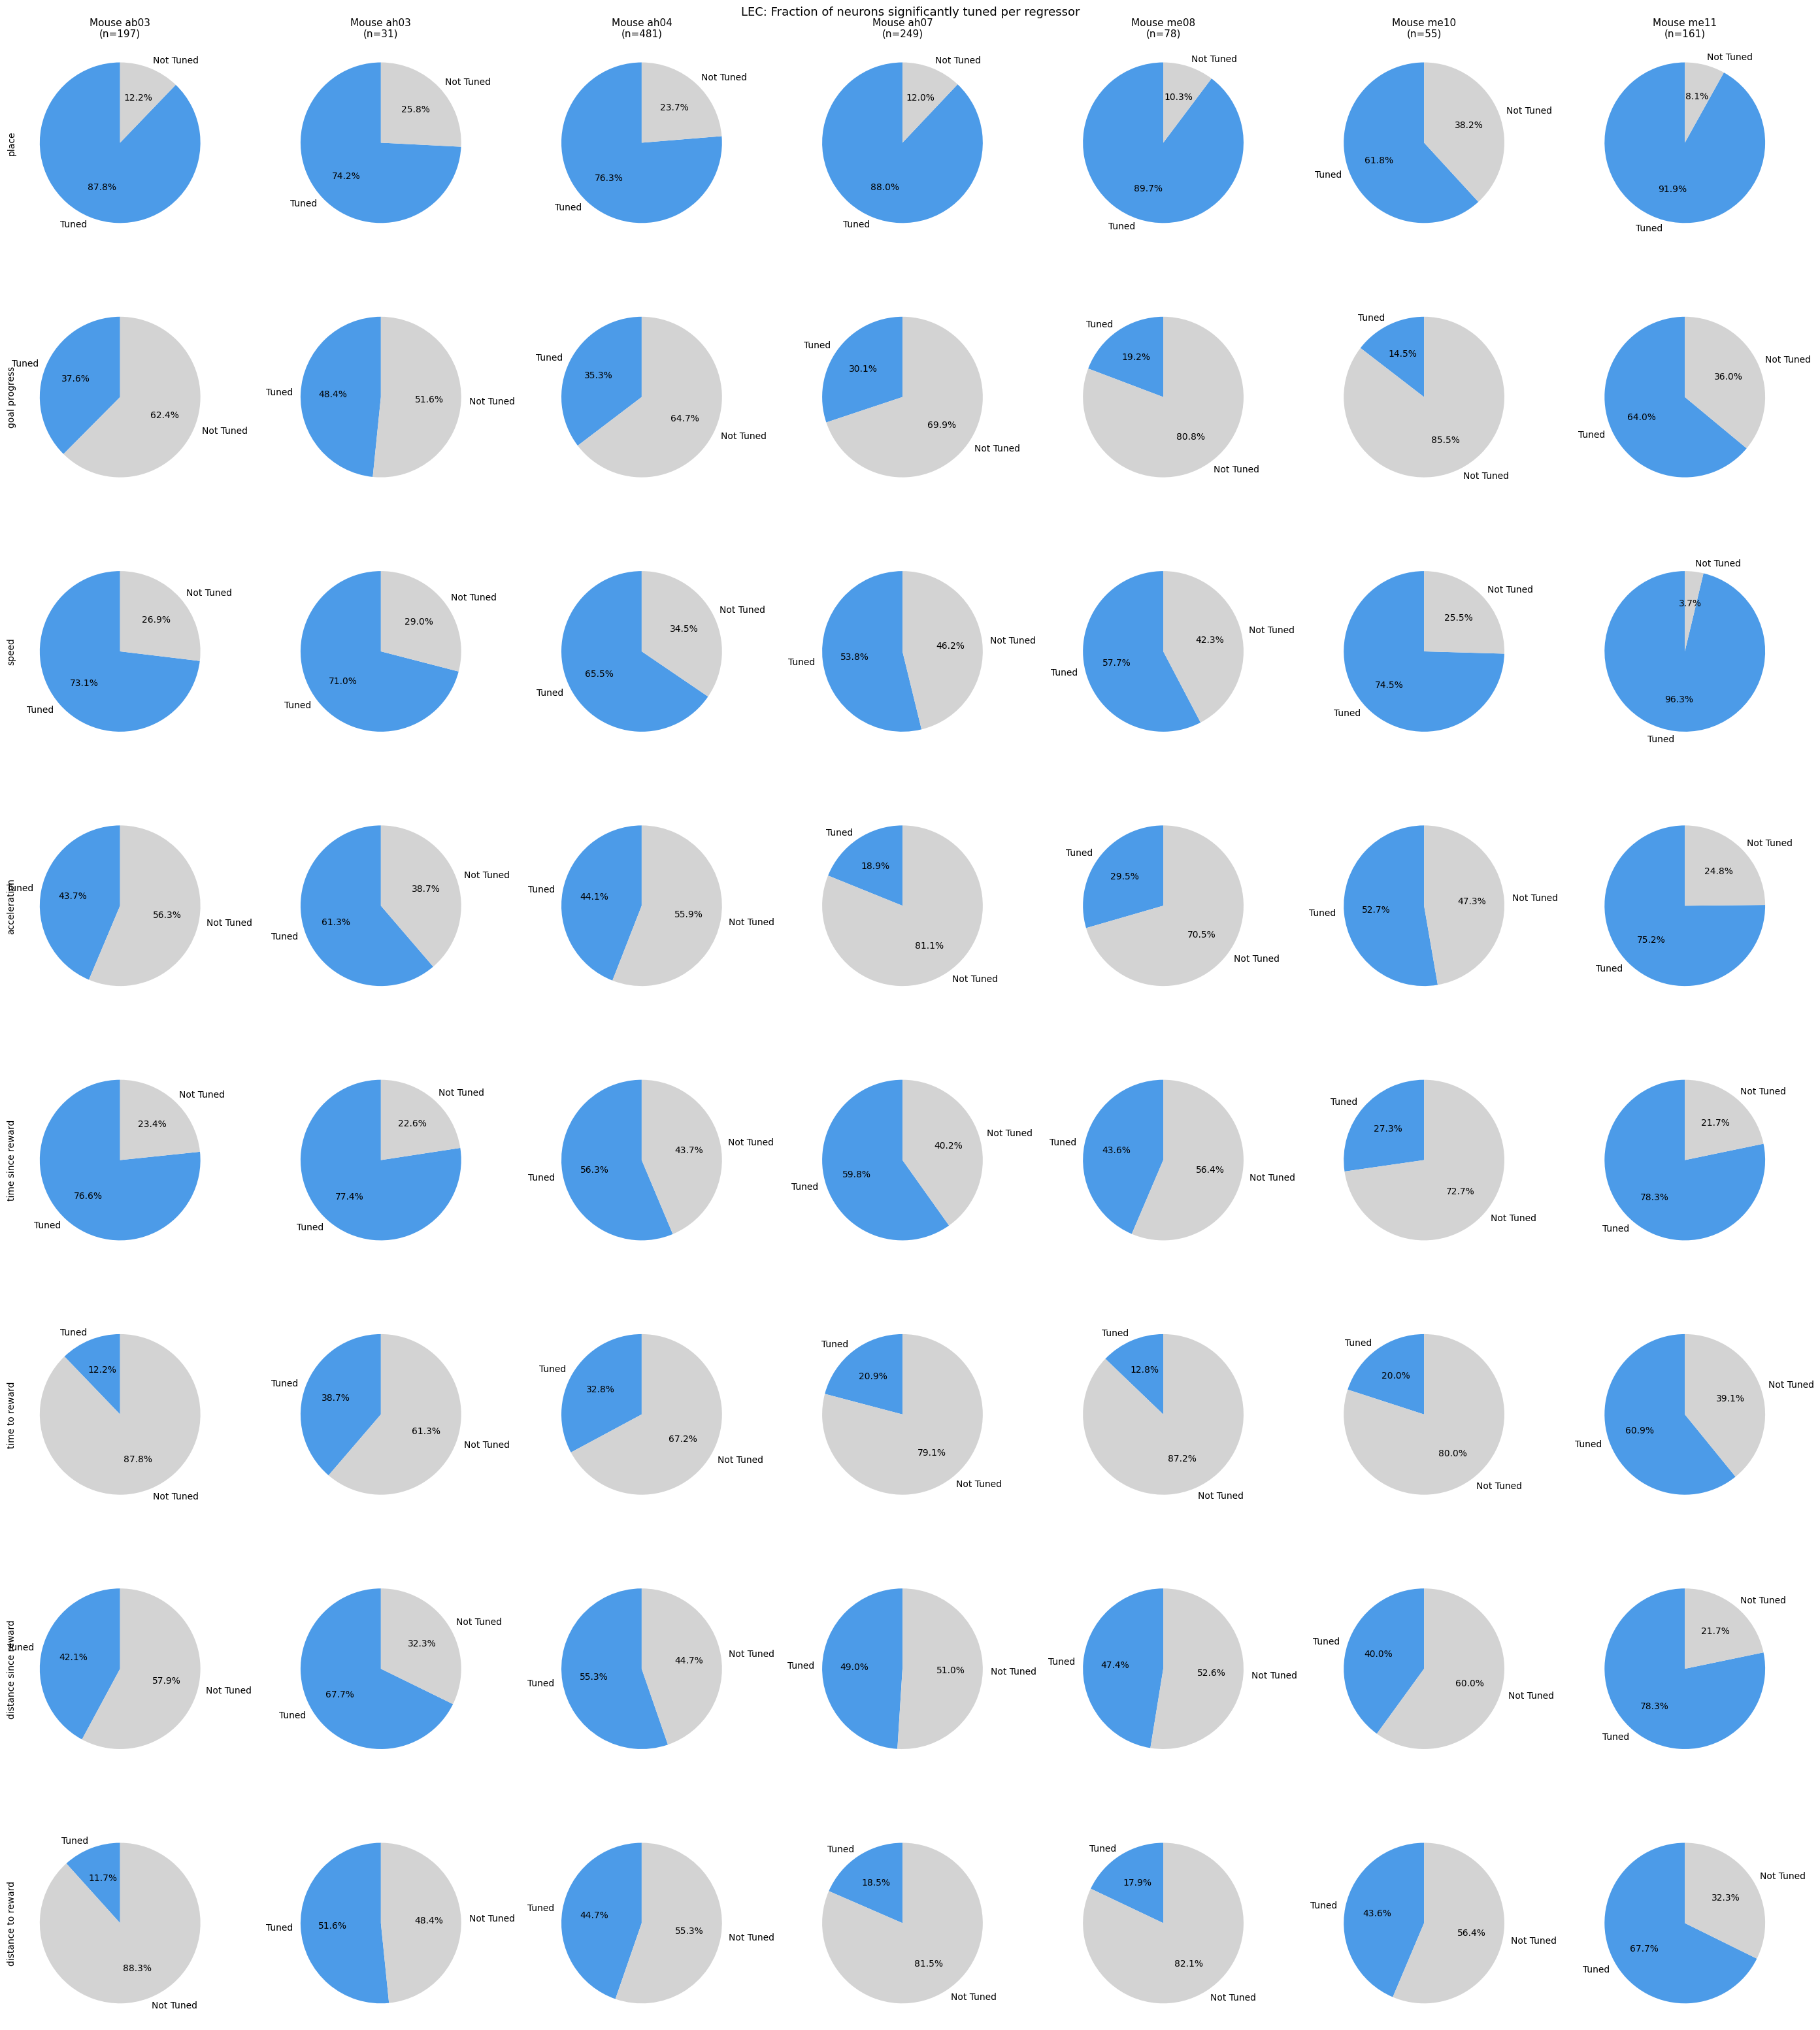

In [7]:
tuned_dict = compute_tuning_arrays(
    GLM_results, Permutation_results,
    regressors_to_include=PFC_REGRESSORS,
)
mouse_tuning_concat = group_tuning_by_mouse(tuned_dict)
plot_tuning_piecharts_binary(mouse_tuning_concat,
                             regressors_to_include=PFC_REGRESSORS)

## No-lookahead variant

Drops `time_to_reward` and `distance_to_reward`. Tests whether the
goal-progress signal survives without forward-looking variables (whose
information about the upcoming reward is partly tautological with goal
progress).

Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023
  Design matrix: 26462 rows × 71 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'distance_from_reward'], parameterization=all_bins)


Processing recording days:   4%|▍         | 1/25 [24:47<9:54:53, 1487.22s/it]


ab03_05092023_06092023
  Design matrix: 26090 rows × 71 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'distance_from_reward'], parameterization=all_bins)


Processing recording days:   8%|▊         | 2/25 [49:27<9:28:37, 1483.37s/it]

...


me11_09122021_10122021
  Design matrix: 27028 rows × 71 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'distance_from_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [7:04:38<10:45, 645.34s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 71 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'distance_from_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [7:08:46<00:00, 1029.06s/it]


ab03_01092023_02092023: tuning array shape = (63, 6)
ab03_05092023_06092023: tuning array shape = (64, 6)
ab03_29082023_30082023: tuning array shape = (70, 6)
ah03_12082021_13082021: tuning array shape = (16, 6)
ah03_18082021_19082021: tuning array shape = (15, 6)
ah04_01122021_02122021: tuning array shape = (117, 6)
ah04_05122021_06122021: tuning array shape = (114, 6)
ah04_07122021_08122021: tuning array shape = (81, 6)
ah04_09122021_10122021: tuning array shape = (99, 6)
ah04_14122021_16122021: tuning array shape = (70, 6)
ah07_01092023_02092023: tuning array shape = (97, 6)
ah07_27082023_28082023: tuning array shape = (80, 6)
ah07_29082023_30082023: tuning array shape = (72, 6)
me08_06092021_09092021: tuning array shape = (23, 6)
me08_10092021_11092021: tuning array shape = (32, 6)
me08_12092021_13092021: tuning array shape = (23, 6)
me10_09122021_10122021: tuning array shape = (28, 6)
me10_14122021_15122021: tuning array shape = (20, 6)
me10_17122021_19122021: tuning array shape =

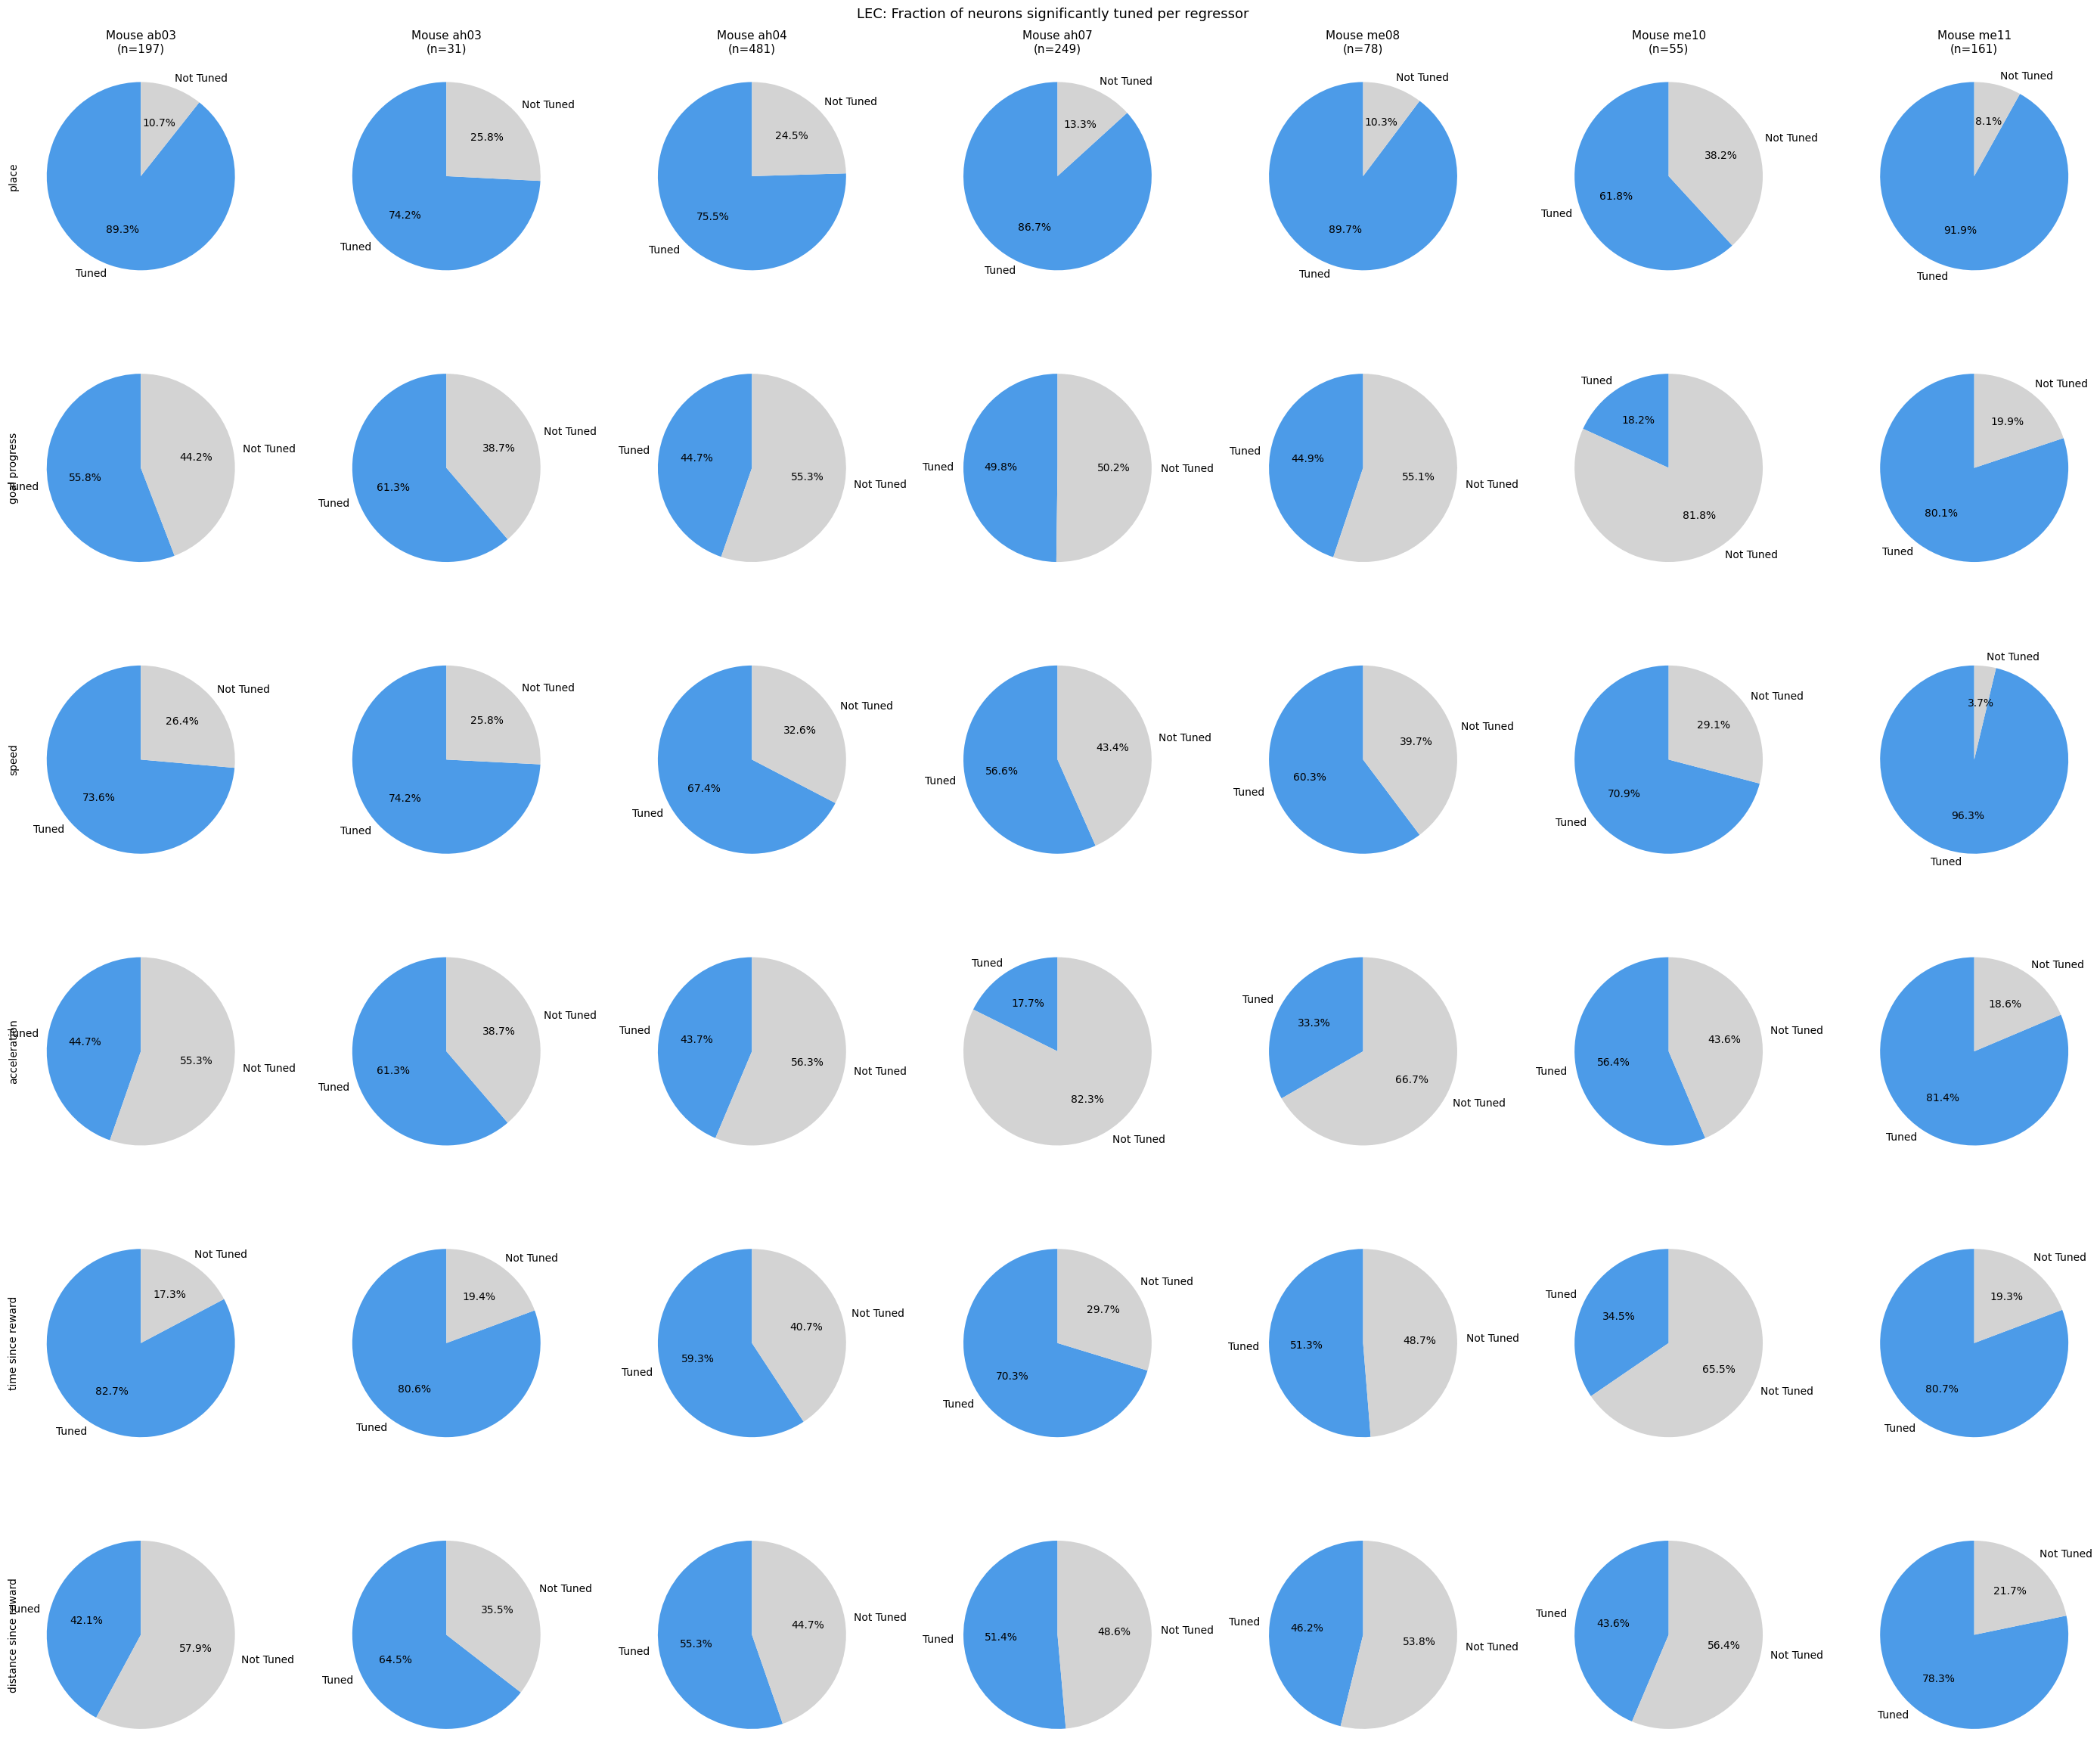

In [8]:
PFC_REGRESSORS_NL = ['place', 'goal_progress', 'speed', 'acceleration',
                     'time_since_reward', 'distance_since_reward']

GLM_results_nl, Permutation_results_nl = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=PFC_REGRESSORS_NL,
)
tuned_dict_nl = compute_tuning_arrays(
    GLM_results_nl, Permutation_results_nl,
    regressors_to_include=PFC_REGRESSORS_NL,
)
mouse_tuning_concat_nl = group_tuning_by_mouse(tuned_dict_nl)
plot_tuning_piecharts_binary(mouse_tuning_concat_nl,
                             regressors_to_include=PFC_REGRESSORS_NL)

## Extended analysis: CPD + joint `time_any` group

Re-fits with `compute_cpd=True` and a joint test of "any time information"
(`time_since` + `time_to` dropped together). Produces the headline GP-vs-time
comparison: simplified pies, time-vs-progress overlap stacked bars, per-neuron
CPD scatter.

In [9]:
reload(glm_analysis_v2)
from glm_analysis_v2 import (
    run_glm_analysis, plot_time_vs_progress_overlap, plot_cpd_time_vs_progress,
)

GLM_results_ext, Permutation_results_ext, CPD_results_ext = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=PFC_REGRESSORS,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
)
print('Done. CPD and joint time_any stored.')

Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023
  Design matrix: 26462 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   4%|▍         | 1/25 [45:24<18:09:51, 2724.65s/it]


ab03_05092023_06092023
  Design matrix: 26090 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   8%|▊         | 2/25 [1:26:51<16:30:50, 2584.80s/it]

...


me11_09122021_10122021
  Design matrix: 27028 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [22:38:32<50:40, 3040.65s/it]  


me11_12122021_13122021
  Design matrix: 24771 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [23:00:00<00:00, 3312.02s/it]

Done. CPD and joint time_any stored.


ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_05092023_06092023: tuning array shape = (64, 8)
ab03_29082023_30082023: tuning array shape = (70, 8)
ah03_12082021_13082021: tuning array shape = (16, 8)
ah03_18082021_19082021: tuning array shape = (15, 8)
ah04_01122021_02122021: tuning array shape = (117, 8)
ah04_05122021_06122021: tuning array shape = (114, 8)
ah04_07122021_08122021: tuning array shape = (81, 8)
ah04_09122021_10122021: tuning array shape = (99, 8)
ah04_14122021_16122021: tuning array shape = (70, 8)
ah07_01092023_02092023: tuning array shape = (97, 8)
ah07_27082023_28082023: tuning array shape = (80, 8)
ah07_29082023_30082023: tuning array shape = (72, 8)
me08_06092021_09092021: tuning array shape = (23, 8)
me08_10092021_11092021: tuning array shape = (32, 8)
me08_12092021_13092021: tuning array shape = (23, 8)
me10_09122021_10122021: tuning array shape = (28, 8)
me10_14122021_15122021: tuning array shape = (20, 8)
me10_17122021_19122021: tuning array shape =

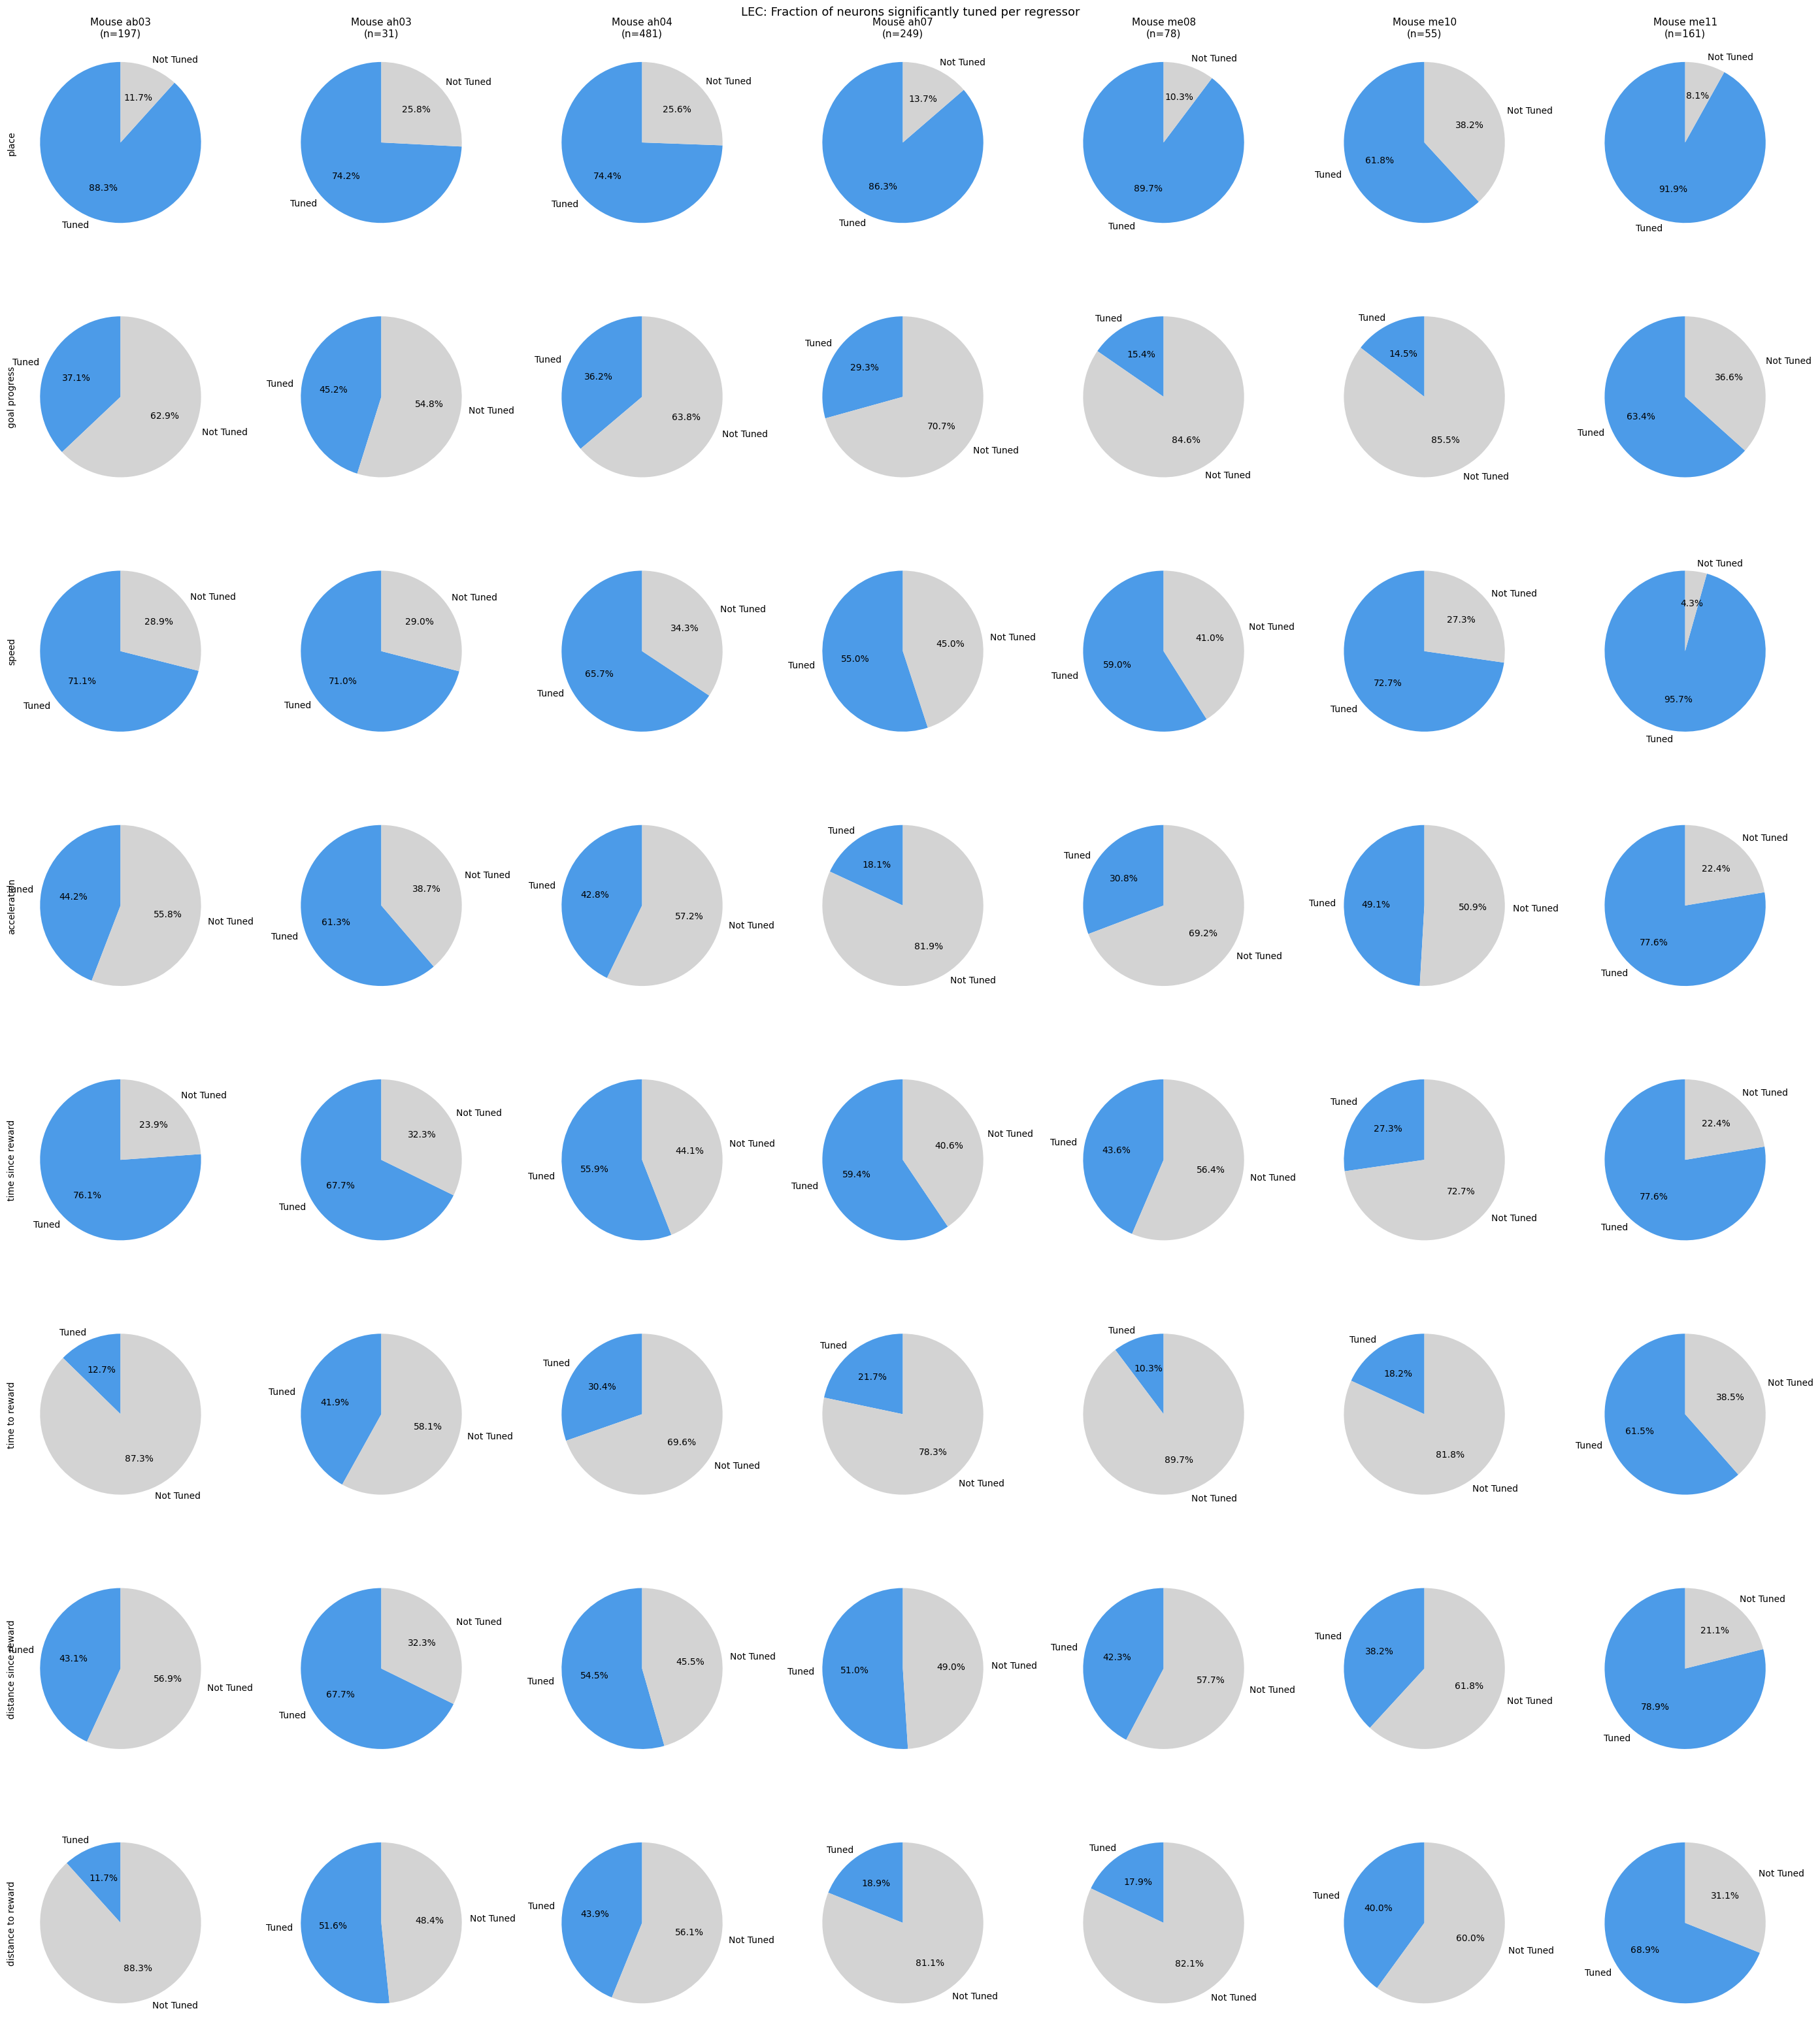

In [10]:
tuned_dict_ext = compute_tuning_arrays(
    GLM_results_ext, Permutation_results_ext,
    regressors_to_include=PFC_REGRESSORS,
)
mouse_tuning_concat_ext = group_tuning_by_mouse(tuned_dict_ext)
plot_tuning_piecharts_binary(mouse_tuning_concat_ext,
                             regressors_to_include=PFC_REGRESSORS)

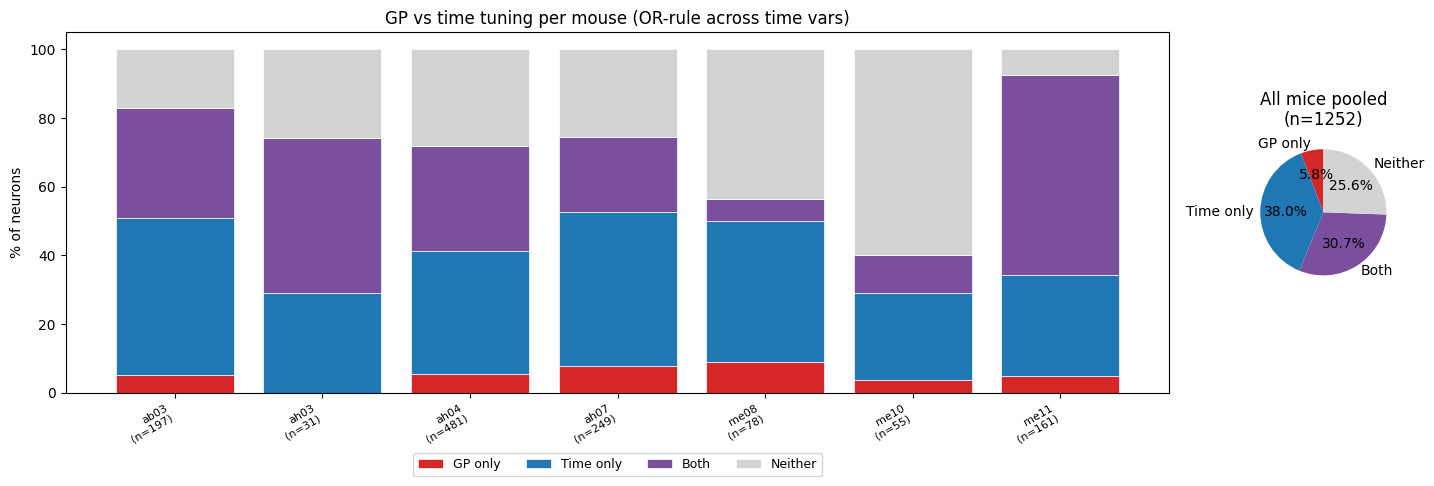

In [11]:
plot_time_vs_progress_overlap(mouse_tuning_concat_ext,
                              regressors_to_include=PFC_REGRESSORS,
                              use_joint_time=False)

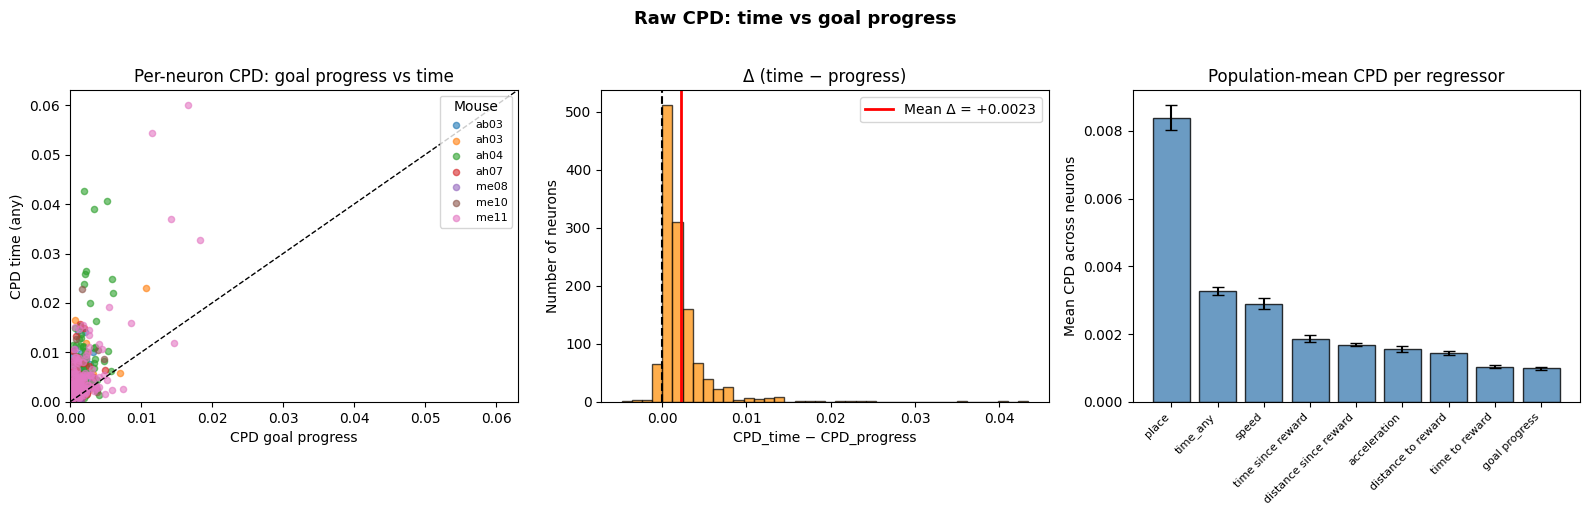

Per-mouse mean Δ (CPD_time_any − CPD_progress):
  ab03: μ=+0.00224  n=197
  ah03: μ=+0.00358  n=31
  ah04: μ=+0.00219  n=481
  ah07: μ=+0.00185  n=249
  me08: μ=+0.00145  n=78
  me10: μ=+0.00255  n=55
  me11: μ=+0.00335  n=161


In [12]:
cpd_gp, cpd_time = plot_cpd_time_vs_progress(CPD_results_ext, group_by_mouse=True)

by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_ext.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        t = cpd.get('time_any', np.nan)
        if not (np.isnan(g) or np.isnan(t)):
            by_mouse_diff[mouse].append(t - g)

print('Per-mouse mean Δ (CPD_time_any − CPD_progress):')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: μ={diffs.mean():+.5f}  n={len(diffs)}')

## Firming up: full-model R², normalized CPD, column-matched

Anchors CPD magnitudes with model-fit quality and runs a column-matched
single-regressor comparison (GP 10 cols vs `time_since_reward` 10 cols).

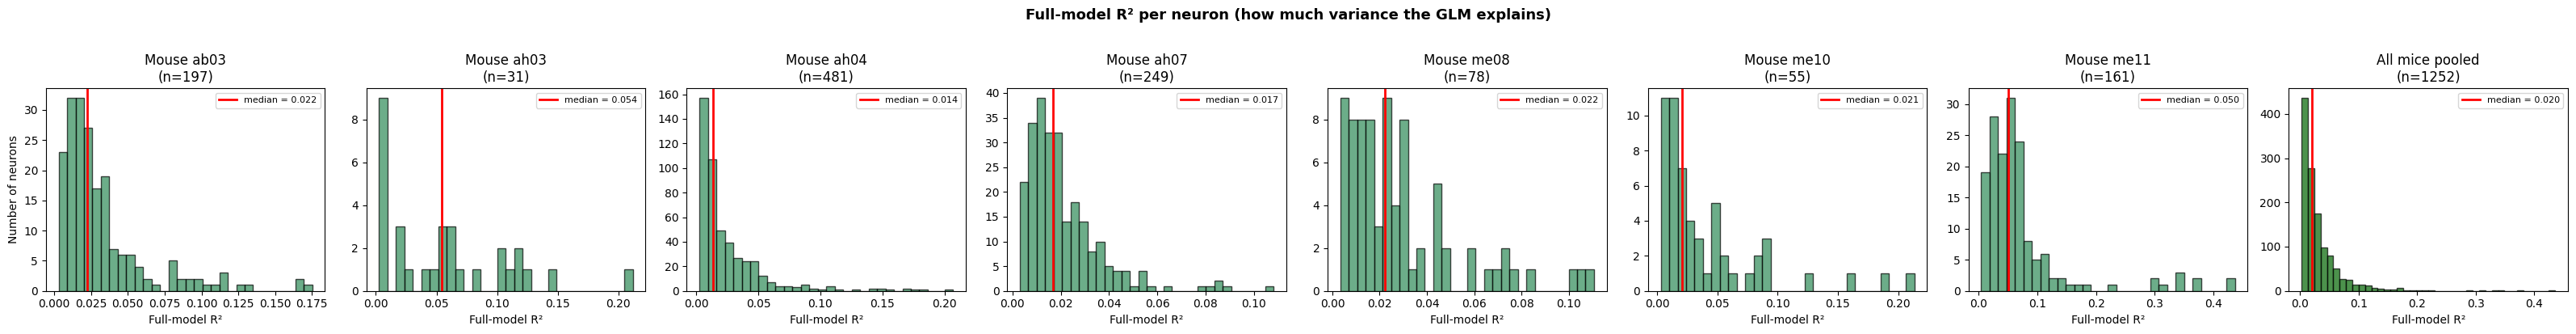

{'ab03': array([0.0155833 , 0.00728194, 0.00478292, 0.02465194, 0.02033797,
        0.00526981, 0.00918906, 0.04280396, 0.04098885, 0.03536839,
        0.01724177, 0.01461308, 0.01699959, 0.11762688, 0.01730089,
        0.04318316, 0.01990723, 0.04311057, 0.01885739, 0.0957751 ,
        0.03895114, 0.17521583, 0.02581052, 0.08155223, 0.0454704 ,
        0.04835643, 0.01251656, 0.09485768, 0.12433311, 0.16656097,
        0.03708478, 0.10222331, 0.035784  , 0.01207119, 0.03048967,
        0.07829622, 0.02338705, 0.02599042, 0.03242666, 0.00873816,
        0.01232944, 0.00911763, 0.0090127 , 0.00636557, 0.00402825,
        0.00786255, 0.01349714, 0.02021159, 0.01837558, 0.02192798,
        0.02775374, 0.03146004, 0.02368507, 0.02446592, 0.01311975,
        0.05947503, 0.00396971, 0.0634529 , 0.01628549, 0.018958  ,
        0.02170923, 0.00332086, 0.04752517, 0.02345802, 0.0290089 ,
        0.02175274, 0.00961541, 0.00922923, 0.00583195, 0.00729053,
        0.02180978, 0.02499337, 0.014740

In [13]:
from glm_analysis_v2 import plot_full_model_r2
plot_full_model_r2(CPD_results_ext)

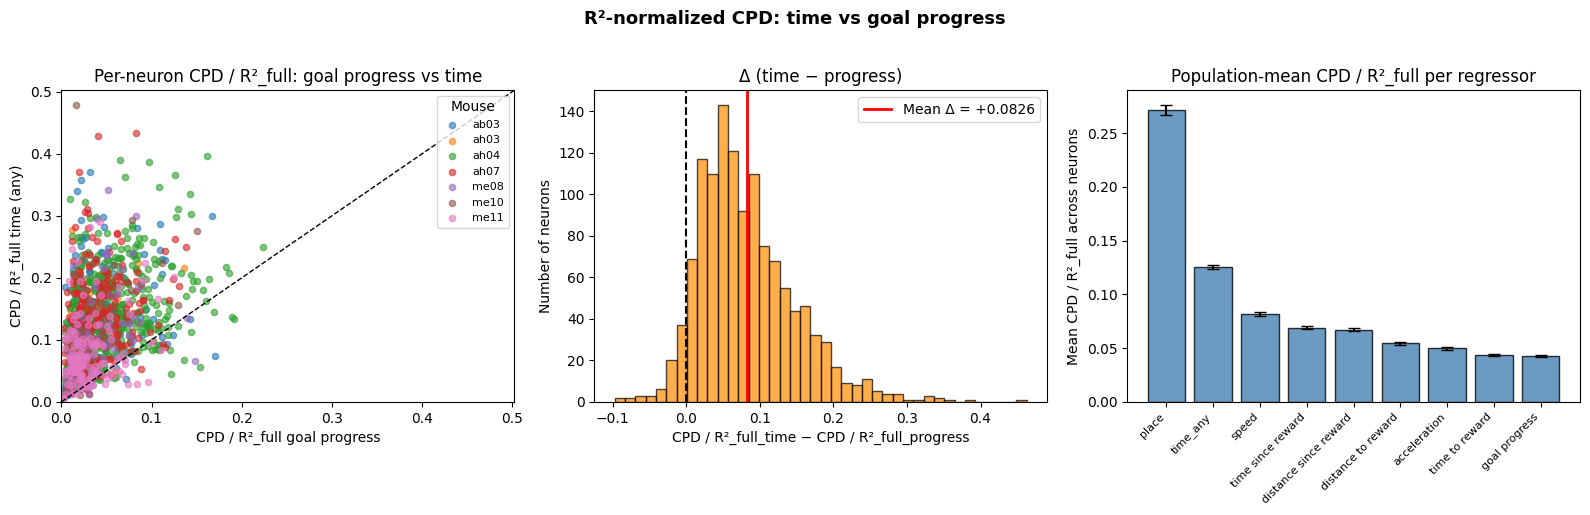

(array([0.02378667, 0.04369503, 0.14204939, ..., 0.09244871, 0.03935176,
        0.07071591]),
 array([0.08897575, 0.24158364, 0.13376112, ..., 0.22404321, 0.09869131,
        0.06820784]))

In [14]:
plot_cpd_time_vs_progress(CPD_results_ext, normalize='r2_full')

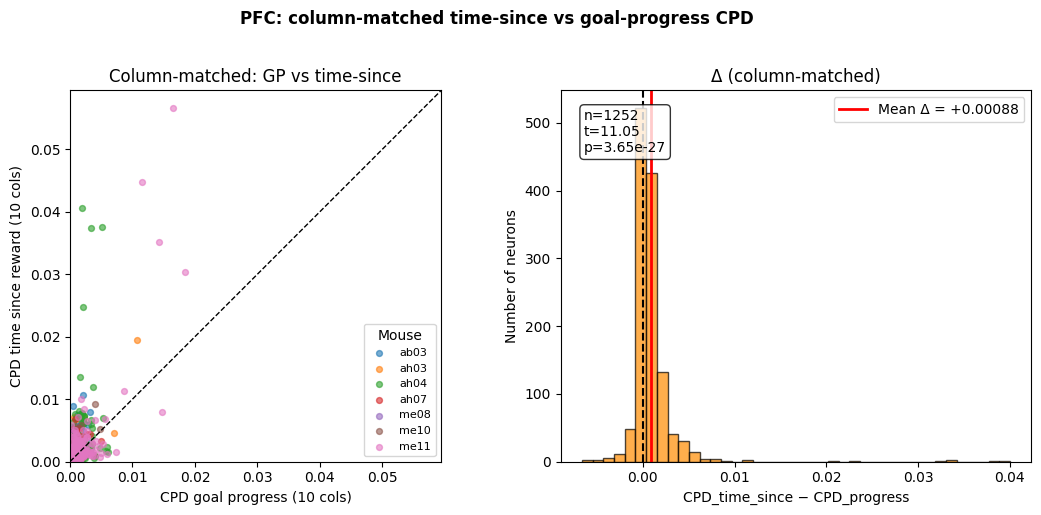

In [15]:
# Column-matched: GP(10) vs time_since(10) — single-regressor, NOT joint.
gp_cpd, ts_cpd, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_ext.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        t = cpd.get('time_from_reward', np.nan)  # canonical = time_since_reward
        if np.isfinite(g) and np.isfinite(t):
            gp_cpd.append(g); ts_cpd.append(t); mouse_tag.append(mouse)
gp_cpd = np.array(gp_cpd); ts_cpd = np.array(ts_cpd); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(gp_cpd[msk], ts_cpd[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(gp_cpd.max(), ts_cpd.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD goal progress (10 cols)')
ax.set_ylabel('CPD time since reward (10 cols)')
ax.set_title('Column-matched: GP vs time-since')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = ts_cpd - gp_cpd
ax.hist(d, bins=40, color='darkorange', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
tval, pval = st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_time_since − CPD_progress')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (column-matched)')
ax.legend()
plt.suptitle('PFC: column-matched time-since vs goal-progress CPD', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## Raised-cosine basis variant (robustness check)

Refits with smooth raised-cosine bumps in place of hard decile binning for the
continuous regressors. If the time-vs-progress conclusion survives, it isn't
an artefact of the hard-binning choice.

In [16]:
GLM_results_rc, Permutation_results_rc, CPD_results_rc = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=PFC_REGRESSORS,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
    continuous_basis='raised_cosine',
)
tuned_dict_rc = compute_tuning_arrays(
    GLM_results_rc, Permutation_results_rc,
    regressors_to_include=PFC_REGRESSORS,
)
mouse_tuning_concat_rc = group_tuning_by_mouse(tuned_dict_rc)
plot_tuning_piecharts_binary(mouse_tuning_concat_rc,
                             regressors_to_include=PFC_REGRESSORS)
plot_time_vs_progress_overlap(mouse_tuning_concat_rc,
                              regressors_to_include=PFC_REGRESSORS)
plot_cpd_time_vs_progress(CPD_results_rc)

Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:748: RuntimeWarning: invalid value encountered in cast
  hd_bin_idx = np.clip(np.floor((hd_all % 360) / 10).astype(int), 0, 35)


  Design matrix: 26462 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   4%|▍         | 1/25 [1:25:56<34:22:32, 5156.34s/it]

...


ah04_01122021_02122021
  Design matrix: 26871 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  24%|██▍       | 6/25 [6:26:26<21:46:50, 4126.88s/it]


ah04_05122021_06122021
  Design matrix: 23121 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  24%|██▍       | 6/25 [8:11:51<25:57:33, 4918.59s/it]


KeyboardInterrupt: 

## 20-bin GP column-matched (GP=20 vs joint `time_any`=20, `distance_any`=20)

`goal_progress` re-binned to 20 cols so it matches both joint 20-col groups.
Removes the column-count advantage that `time_any` / `distance_any` had over
the 10-bin GP in the extended section above. Design matrix grows from 91 to
101 cols.

Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023
  Design matrix: 26462 rows × 101 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   4%|▍         | 1/25 [1:34:11<37:40:41, 5651.71s/it]


ab03_05092023_06092023
  Design matrix: 26090 rows × 101 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   8%|▊         | 2/25 [3:06:31<35:41:08, 5585.61s/it]

...


me11_09122021_10122021
  Design matrix: 27028 rows × 101 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [18:48:20<25:17, 1517.93s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 101 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [18:58:04<00:00, 2731.38s/it]


ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_05092023_06092023: tuning array shape = (64, 8)
ab03_29082023_30082023: tuning array shape = (70, 8)
ah03_12082021_13082021: tuning array shape = (16, 8)
ah03_18082021_19082021: tuning array shape = (15, 8)
ah04_01122021_02122021: tuning array shape = (117, 8)
ah04_05122021_06122021: tuning array shape = (114, 8)
ah04_07122021_08122021: tuning array shape = (81, 8)
ah04_09122021_10122021: tuning array shape = (99, 8)
ah04_14122021_16122021: tuning array shape = (70, 8)
ah07_01092023_02092023: tuning array shape = (97, 8)
ah07_27082023_28082023: tuning array shape = (80, 8)
ah07_29082023_30082023: tuning array shape = (72, 8)
me08_06092021_09092021: tuning array shape = (23, 8)
me08_10092021_11092021: tuning array shape = (32, 8)
me08_12092021_13092021: tuning array shape = (23, 8)
me10_09122021_10122021: tuning array shape = (28, 8)
me10_14122021_15122021: tuning array shape = (20, 8)
me10_17122021_19122021: tuning array shape =

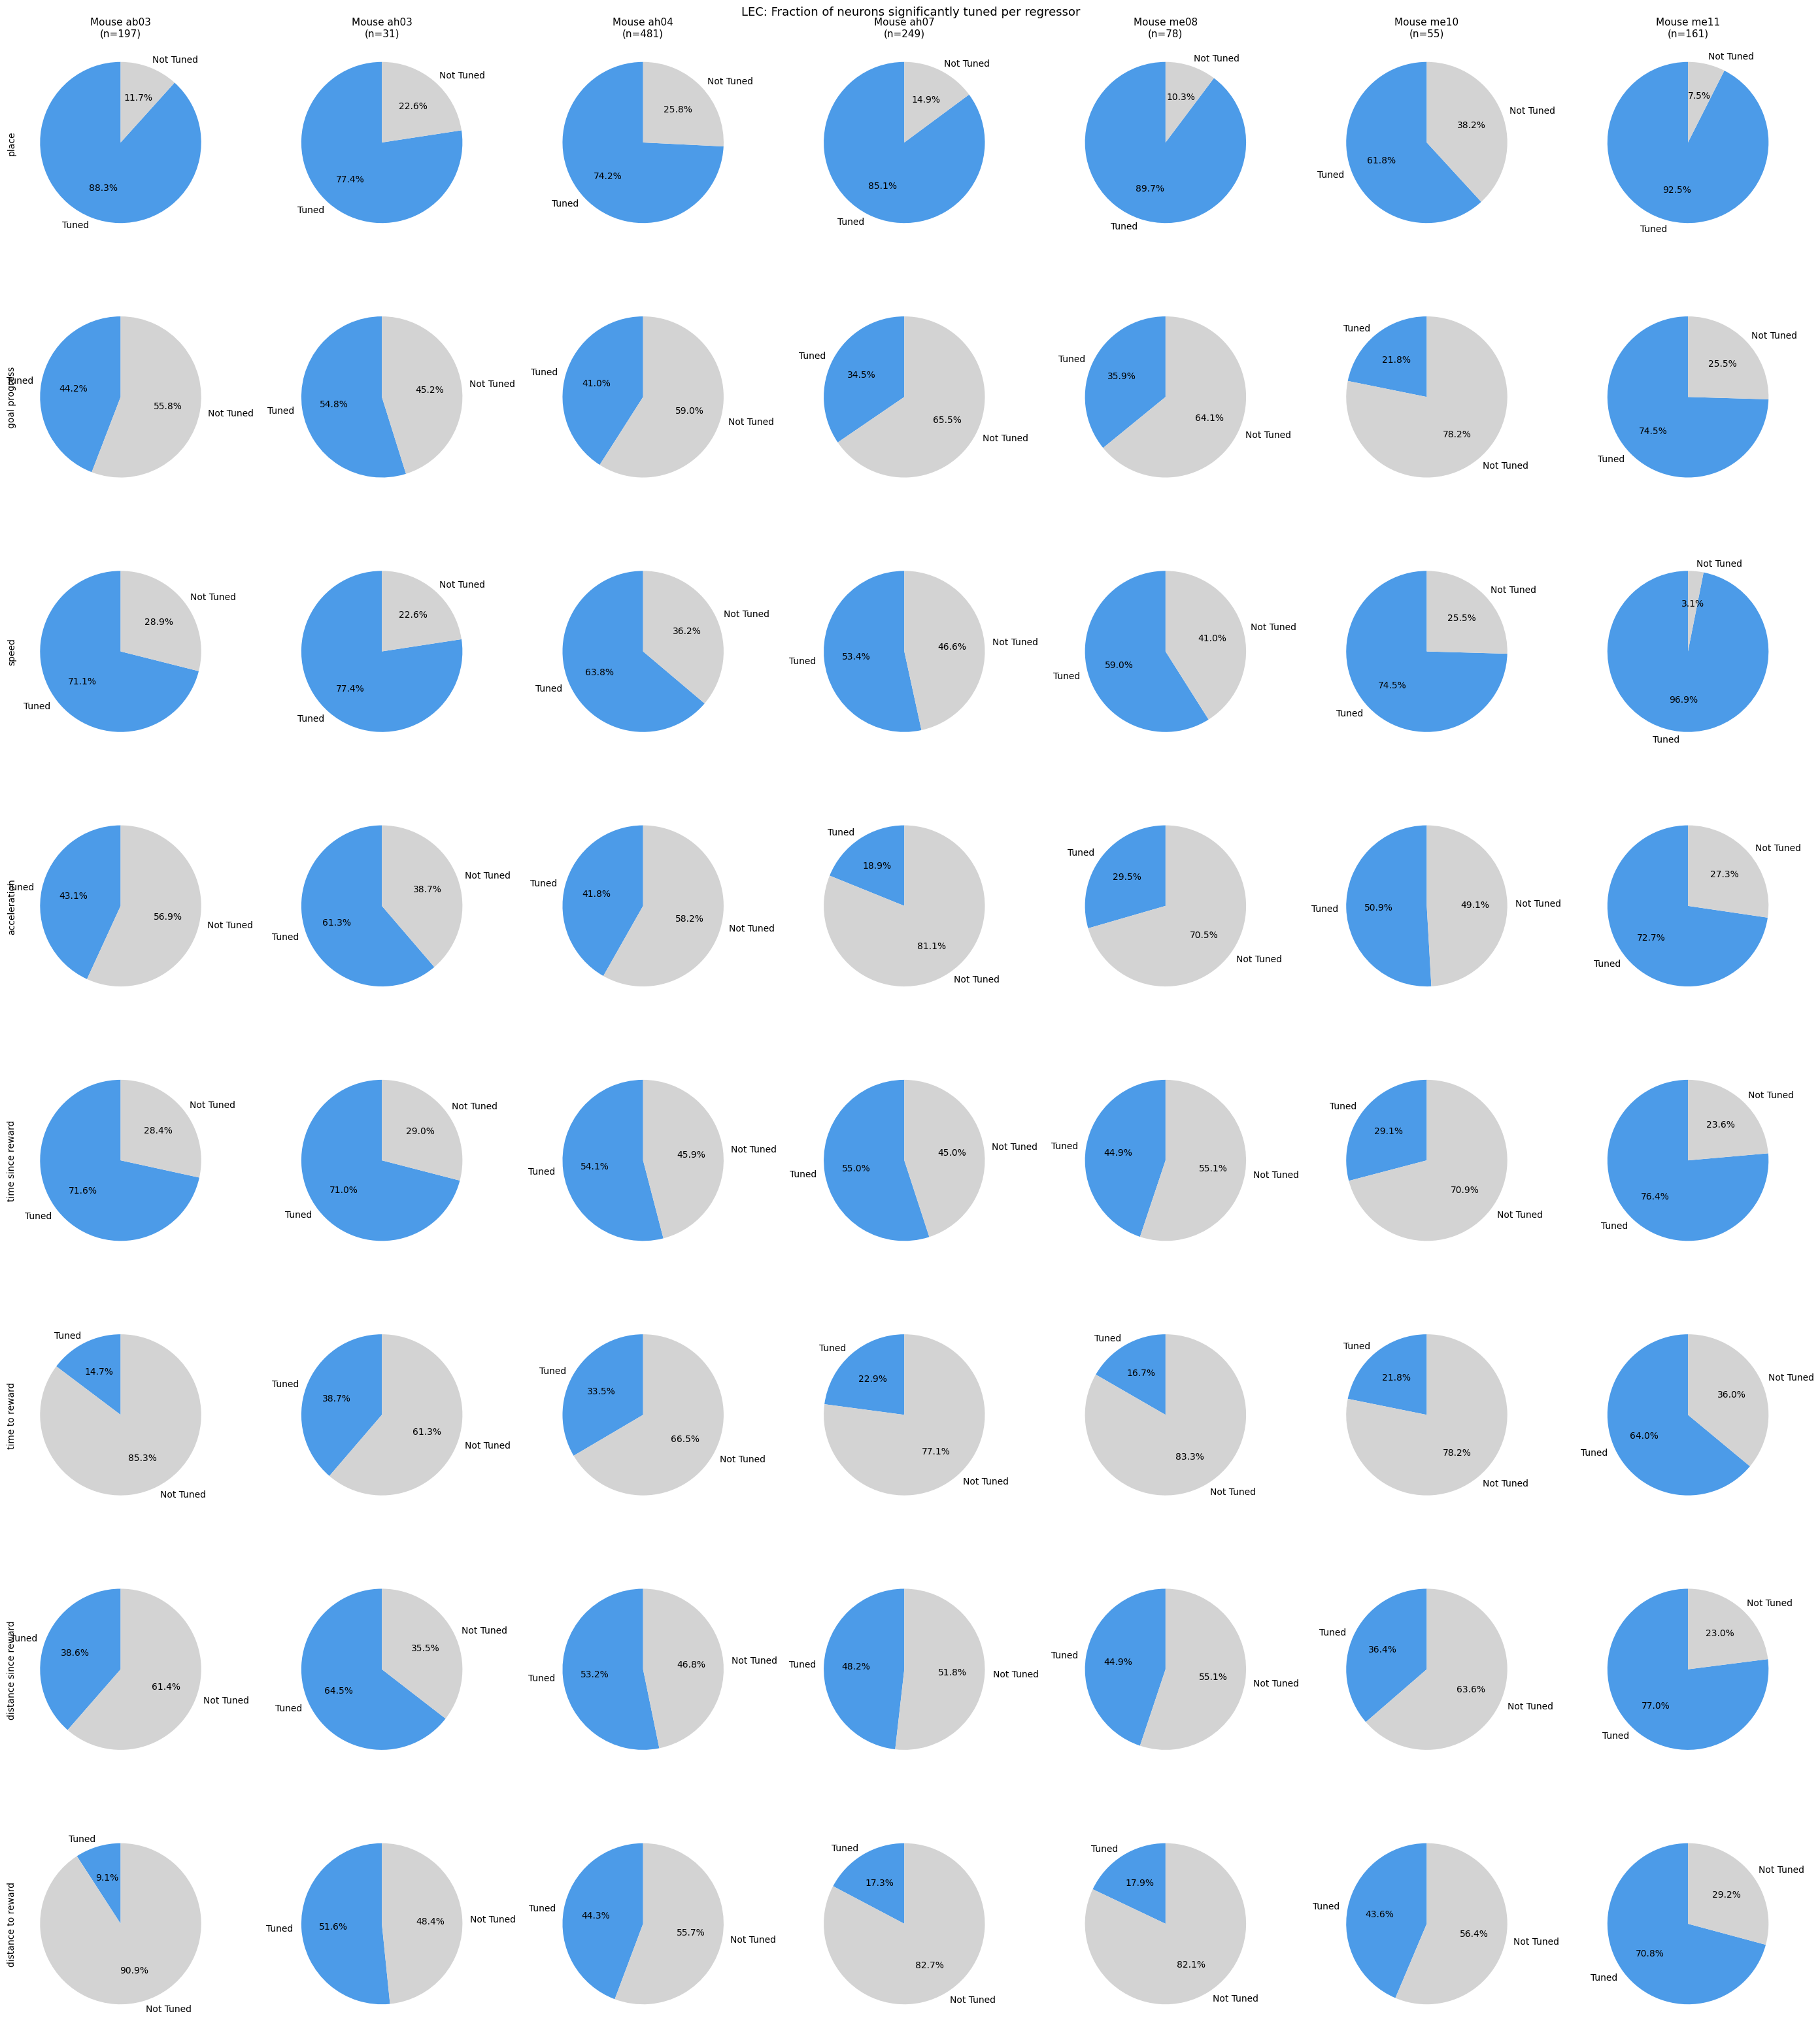

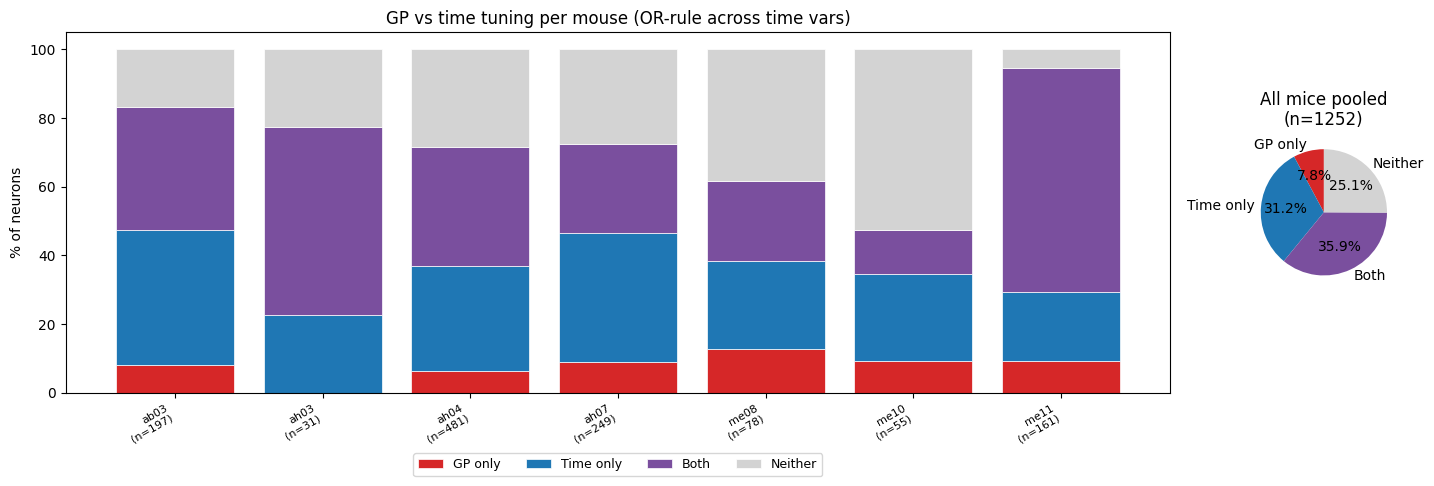

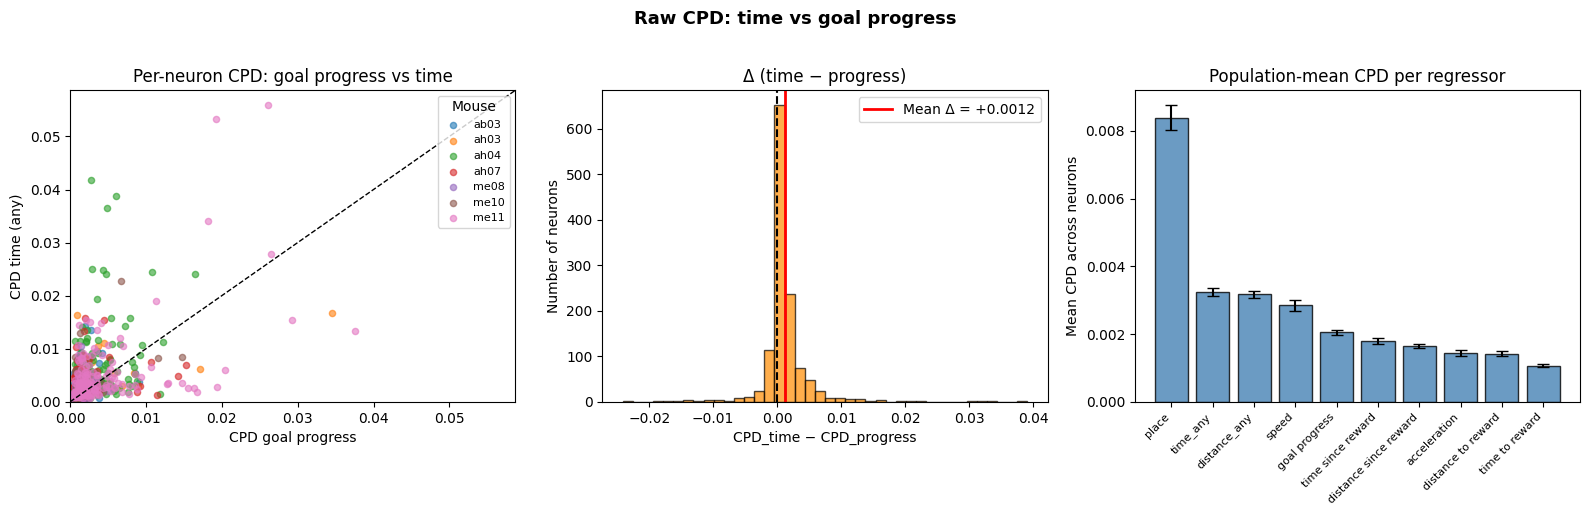

(array([0.00106214, 0.00057431, 0.00085615, ..., 0.00117557, 0.00280466,
        0.00358788]),
 array([0.00137903, 0.00172897, 0.00062435, ..., 0.0021769 , 0.00365209,
        0.00223799]))

In [17]:
GLM_results_gp20, Permutation_results_gp20, CPD_results_gp20 = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=PFC_REGRESSORS,
    gp_n_bins=20,
    compute_cpd=True,
    joint_drop_groups=[
        ('time_any',     ['time_since_reward', 'time_to_reward']),
        ('distance_any', ['distance_since_reward', 'distance_to_reward']),
    ],
)
tuned_dict_gp20 = compute_tuning_arrays(
    GLM_results_gp20, Permutation_results_gp20,
    regressors_to_include=PFC_REGRESSORS, gp_n_bins=20,
)
mouse_tuning_concat_gp20 = group_tuning_by_mouse(tuned_dict_gp20)
plot_tuning_piecharts_binary(mouse_tuning_concat_gp20,
                             regressors_to_include=PFC_REGRESSORS)
plot_time_vs_progress_overlap(mouse_tuning_concat_gp20,
                              regressors_to_include=PFC_REGRESSORS)
plot_cpd_time_vs_progress(CPD_results_gp20, group_by_mouse=True)

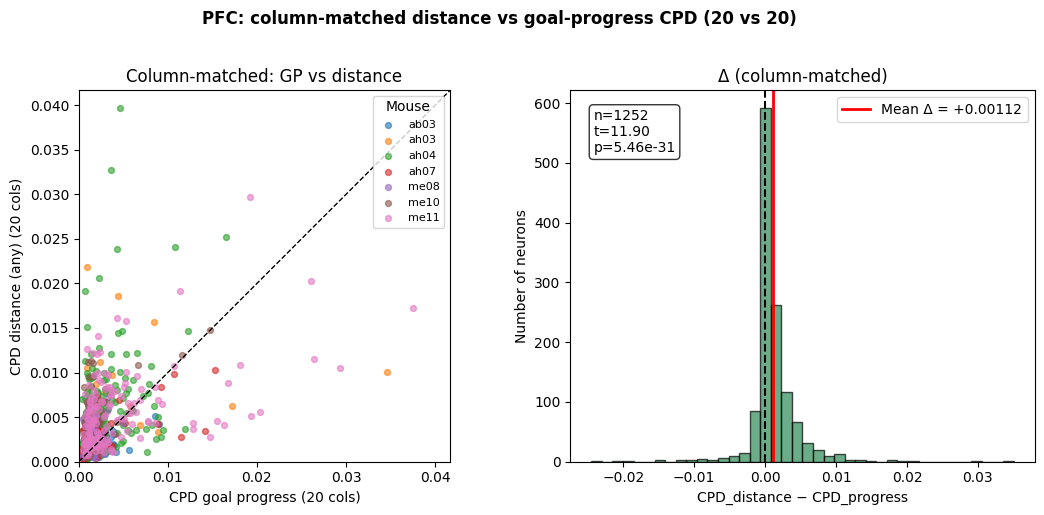

In [18]:
# Column-matched distance: GP(20 cols) vs distance_any(20 cols)
gp_cpd, da_cpd, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_gp20.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        d = cpd.get('distance_any', np.nan)
        if np.isfinite(g) and np.isfinite(d):
            gp_cpd.append(g); da_cpd.append(d); mouse_tag.append(mouse)
gp_cpd = np.array(gp_cpd); da_cpd = np.array(da_cpd); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(gp_cpd[msk], da_cpd[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(gp_cpd.max(), da_cpd.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD goal progress (20 cols)')
ax.set_ylabel('CPD distance (any) (20 cols)')
ax.set_title('Column-matched: GP vs distance')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = da_cpd - gp_cpd
ax.hist(d, bins=40, color='seagreen', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
tval, pval = st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_distance − CPD_progress')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (column-matched)')
ax.legend()
plt.suptitle('PFC: column-matched distance vs goal-progress CPD (20 vs 20)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## Reference-coded sanity check

Re-fits one recday under the textbook reference coding (intercept + drop first
bin of each block) and asserts that R², CPD, and ΔR² match the default
no-intercept all-bins fit to numerical precision. F-stats differ by a constant
df-scaling but the substantive significance flags agree.

In [19]:
mr_check = mouse_recdays[0]
data_check = {mr_check: data_dic[mr_check]}
np.random.seed(42)
GA, PA, CA = run_glm_analysis(
    [mr_check], data_check, regressors_to_include=PFC_REGRESSORS,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
)
np.random.seed(42)
GR, PR, CR = run_glm_analysis(
    [mr_check], data_check, regressors_to_include=PFC_REGRESSORS,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
    parameterization='reference_coded',
)

nids = sorted(set(CA[mr_check].keys()) & set(CR[mr_check].keys()))
r2_diffs, cpd_diffs, dr2_diffs = [], {}, {}
for nid in nids:
    a, r = CA[mr_check][nid], CR[mr_check][nid]
    r2_diffs.append(abs(a['__r2_full__'] - r['__r2_full__']))
    for k in a:
        if k.startswith('__') or k not in r: continue
        cpd_diffs.setdefault(k, []).append(abs(a[k] - r[k]))
        dr2_diffs.setdefault(k, []).append(abs(a['__delta_r2__'][k] - r['__delta_r2__'][k]))

print(f'Comparing {len(nids)} neurons in {mr_check}')
print(f'max |Δ r2_full|       = {max(r2_diffs):.2e}')
print(f'max |Δ CPD| (any reg) = {max(max(v) for v in cpd_diffs.values()):.2e}')
print(f'max |Δ ΔR²| (any reg) = {max(max(v) for v in dr2_diffs.values()):.2e}')
assert max(r2_diffs) < 1e-8
assert max(max(v) for v in cpd_diffs.values()) < 1e-8
assert max(max(v) for v in dr2_diffs.values()) < 1e-8

ta = compute_tuning_arrays(GA, PA, regressors_to_include=PFC_REGRESSORS)
tr = compute_tuning_arrays(GR, PR, regressors_to_include=PFC_REGRESSORS,
                           parameterization='reference_coded')
agree = int(np.sum(ta[mr_check] == tr[mr_check]))
total = int(ta[mr_check].size)
print(f'tuning-flag agreement: {agree}/{total}  ({100*agree/total:.1f}%)')
print('PFC sanity check PASSED — parameterization-invariant.')

Processing recording days:   0%|          | 0/1 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:748: RuntimeWarning: invalid value encountered in cast
  raise ValueError(


  Design matrix: 26462 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   0%|          | 0/1 [00:00<?, ?it/s]


ab03_01092023_02092023
  Design matrix: 26462 rows × 84 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=reference_coded)


Processing recording days: 100%|██████████| 1/1 [01:09<00:00, 69.45s/it]

Comparing 63 neurons in ab03_01092023_02092023
max |Δ r2_full|       = 2.22e-16
max |Δ CPD| (any reg) = 6.66e-16
max |Δ ΔR²| (any reg) = 6.35e-16
ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_01092023_02092023: tuning array shape = (63, 8)
tuning-flag agreement: 454/504  (90.1%)
PFC sanity check PASSED — parameterization-invariant.
